In [ ]:
import os
import shutil
import json
import subprocess

# 네트워크 드라이브 경로 활성화를 위해 해당 경로 접근
def activate_network_drive(path):
    try:
        # Windows의 경우 dir 명령어로 경로 접근
        if os.name == 'nt':
            subprocess.run(['dir', path], shell=True, check=True)
        # Linux/Unix의 경우 ls 명령어로 경로 접근 
        else:
            subprocess.run(['ls', path], check=True)
        # print(f"네트워크 드라이브 경로 {path} 활성화 완료")
    except:
        print(f"네트워크 드라이브 경로 {path} 활성화 실패")

# 모델 파일 경로 설정
source_path = r".\best_model"
target_path = r"V:\jupyter\MFT_TAB\NSGA2_natural_convection_v2\model\model_251010"

# 모델 이름과 라벨 정의
model_names = [
    "MFT_1MW_260515_Lmt_LightGBM_260515",
    "MFT_1MW_260515_Llt_LightGBM_260515",
]

# 각 모델 파일에 대해
for model_name in model_names:

    print(f"\n{model_name}")

    # 소스 경로와 타겟 경로 설정
    source_model_dir = os.path.join(source_path, model_name)
    source_model_path = os.path.join(source_model_dir, "test_R2", "model.txt")
    target_model_dir = os.path.join(target_path, model_name, "test_R2")
    target_model_path = os.path.join(target_model_dir, "model.txt")
    
    # 각 모델 폴더 경로 활성화
    activate_network_drive(source_model_dir)
    activate_network_drive(os.path.join(source_model_dir, "test_R2"))
    
    # best_values.json 파일 경로
    best_values_path = os.path.join(source_path, model_name, "best_values.json")
    
    # 타겟 디렉토리가 없으면 생성
    os.makedirs(target_model_dir, exist_ok=True)
    
    # 파일 복사 및 성능 지표 출력
    try:
        # 파일 복사 전에 소스 파일이 있는지 확인
        if not os.path.exists(source_model_path):
            print(f"\n소스 모델 파일이 없습니다: {model_name}")
            continue
            
        # 파일 복사
        shutil.copy2(source_model_path, target_model_path)
        print(f"모델 파일 복사 완료: {model_name}")
        
        # best_values.json 파일 읽기
        if os.path.exists(best_values_path):
            with open(best_values_path, 'r') as f:
                content = f.read()
                # JSON 형식 오류 수정
                content = content.replace("'", '"')  # 작은따옴표를 큰따옴표로 변경
                content = content.replace("None", "null")  # None을 null로 변경
                content = content.replace("True", "true")  # True를 true로 변경
                content = content.replace("False", "false")  # False를 false로 변경
                
                try:
                    metrics = json.loads(content)
                    print(f"Test R2: {metrics.get('test_R2', 'N/A')}")
                    mape = metrics.get('test_MAPE', 'N/A')
                    if mape != 'N/A':
                        print(f"Test MAPE: {mape * 100}")
                    else:
                        print(f"Test MAPE: {mape}")
                except json.JSONDecodeError:
                    # JSON 파싱 실패 시 파일 내용 직접 파싱
                    import re
                    r2_match = re.search(r'"test_R2":\s*([\d.]+)', content)
                    mape_match = re.search(r'"test_MAPE":\s*([\d.]+)', content)
                    
                    if r2_match:
                        print(f"Test R2: {float(r2_match.group(1))}")
                    if mape_match:
                        print(f"Test MAPE: {float(mape_match.group(1)) * 100}")
        else:
            print("best_values.json 파일을 찾을 수 없습니다")
            
    except Exception as e:
        print(f"❌ 모델 파일 복사 실패: {model_name} 🚫")
        print(f"에러: {str(e)}")



MFT_TAB_nc_v2_Lmt1_LightGBM_251010
네트워크 드라이브 경로 V:\jupyter\MFT_TAB\MFT_TAB_natural_convection_regression_v2\best_model\MFT_TAB_nc_v2_Lmt1_LightGBM_251010 활성화 실패
네트워크 드라이브 경로 V:\jupyter\MFT_TAB\MFT_TAB_natural_convection_regression_v2\best_model\MFT_TAB_nc_v2_Lmt1_LightGBM_251010\test_R2 활성화 실패


FileNotFoundError: [WinError 3] 지정된 경로를 찾을 수 없습니다: 'V:\\'

In [1]:
# load model

import os

print("start")


import lightgbm as lgb
import matplotlib.pyplot as plt

import numpy as np
import math


model_names = [
    "MFT_1MW_260515_Lmt_LightGBM_260515",
    "MFT_1MW_260515_Llt_LightGBM_260515",
]

model_labels = [
    "Lmt",
    "Llt",
]

# dict에 담아서 관리
models = {}
for name, label in zip(model_names, model_labels):
    model_path = f"./best_model/{name}/test_R2/model.txt"
    
    # 파일 존재 여부 확인
    if not os.path.exists(model_path):
        print(f"모델 파일이 존재하지 않습니다: {model_path}")
        continue
        
    try:
        print(f"Loading model: {name}")
        models[label] = lgb.Booster(model_file=model_path)
    except Exception as e:
        print(f"모델 로딩 중 에러 발생: {name}")
        print(f"에러 메시지: {str(e)}")

start
Loading model: MFT_1MW_260515_Lmt_LightGBM_260515
Loading model: MFT_1MW_260515_Llt_LightGBM_260515


In [6]:
models["Llt"].predict([[6, 60, 4, 1, 42, 8, 452, 49, 385.5, 628, 44.7, 29.1, 40.8, 27.4, 49.1, 15.8, 43.3, 16.3, 49, 0.3, 0.86, 0.53, 0.43, 0.43, 194.4, 5.01552, 1.170288, 11.0808, 1.61595, 53.30448, 5.01552, 115.406046, 20.673954, 540.08, 332.84, 43.96, 147.58, 0.376367615, 1, 0.425905728, 0.452855027, 187.4, 483.6, 476.412092, 801.012092, 147.2, 484.6, 212.03104, 592.63104]])

array([4.50790459])

In [41]:
import array
import numpy as np
import pandas as pd



COLUMN_ORDER = [
    "N1", "N2", "N2_main", "N2_side",
    "w1", "l1", "l2", "h1",
    "w1c_space_x", "w1w2_space_x", "w2c_space_x",
    "w1c_space_y", "w1w2_space_y", "w2w2_space_y", "w2c_space_y",
    "w1c_space_z", "w2c_space_z",
    "window_ratio", "wh1", "wh2", "wff1", "wff2"
]


def _to_dataframe(input_data):
    if isinstance(input_data, pd.DataFrame):
        df = input_data.copy()
        missing_cols = [col for col in COLUMN_ORDER if col not in df.columns]
        if missing_cols:
            raise ValueError(f"입력 DataFrame에 필요한 컬럼이 없습니다: {missing_cols}")
        return df[COLUMN_ORDER].reset_index(drop=True)

    arr = np.asarray(input_data, dtype=object)

    if arr.ndim == 1:
        if len(arr) != len(COLUMN_ORDER):
            raise ValueError(
                f"1차원 입력 길이는 {len(COLUMN_ORDER)}여야 합니다. 현재: {len(arr)}"
            )
        arr = np.array([arr], dtype=float)

    elif arr.ndim == 2:
        if arr.shape[1] != len(COLUMN_ORDER):
            raise ValueError(
                f"2차원 입력의 컬럼 수는 {len(COLUMN_ORDER)}여야 합니다. 현재: {arr.shape[1]}"
            )
        arr = arr.astype(float)

    else:
        raise ValueError("입력은 DataFrame, 1D numpy/list, 2D numpy/list 여야 합니다.")

    return pd.DataFrame(arr, columns=COLUMN_ORDER)


def _validation_check_one_row(row):
    result = True
    row = row.copy()

    if row["N2_side"] != 0:
        nwl_t = (
            row["l2"]
            - row["w1c_space_y"]
            - row["w1w2_space_y"]
            - row["w2c_space_y"]
            - row["w2w2_space_y"]
        )
    else:
        nwl_t = (
            row["l2"]
            - row["w1c_space_y"]
            - row["w1w2_space_y"]
            - row["w2c_space_y"]
        )
    row["nwl_t"] = nwl_t

    N2_main = row["N2_main"]
    N2_side = row["N2_side"]

    # net window length
    nwl1 = nwl_t * row["window_ratio"]
    nwl2 = nwl_t - nwl1

    if (N2_main + N2_side) == 0:
        nwl2_main = 0
        nwl2_side = 0
        result = False
    else:
        nwl2_main = nwl2 * N2_main / (N2_main + N2_side)
        nwl2_side = nwl2 * N2_side / (N2_main + N2_side)

    row["nwl1"] = nwl1
    row["nwl2"] = nwl2
    row["nwl2_main"] = nwl2_main
    row["nwl2_side"] = nwl2_side

    # net window height
    nwh1 = (row["h1"] - 2 * row["w1c_space_z"]) * row["wh1"]
    nwh2 = (row["h1"] - 2 * row["w2c_space_z"]) * row["wh2"]
    row["nwh1"] = nwh1
    row["nwh2"] = nwh2

    coil_width1 = nwl1 * row["wff1"]

    if row["N2"] == 0:
        coil_width2 = np.inf
        result = False
    else:
        coil_width2 = (nwl2 * row["wff2"]) / row["N2"]

    row["coil_width1"] = coil_width1
    row["coil_width2"] = coil_width2

    # 2차 측 권선 간 간격
    if row["N2"] <= 1:
        coil_gap_layer = -np.inf
        result = False
    else:
        coil_gap_layer = (nwl2 - (coil_width2 * row["N2"])) / (row["N2"] - 1)
    row["coil_gap_layer"] = coil_gap_layer

    # 1차 측 높이 방향 권선 간 간격
    if row["N1"] <= 1:
        coil_gap_height = -np.inf
        result = False
    else:
        coil_gap_height = (nwh1 - (coil_width1 * row["N1"])) / (row["N1"] - 1)
    row["coil_gap_height"] = coil_gap_height

    # 1차 측 fill factor
    if nwh1 == 0:
        fill_factor = np.inf
        result = False
    else:
        fill_factor = coil_width1 * row["N1"] / nwh1
    row["fill_factor"] = fill_factor

    # window 내부 gap 공간
    sl1 = 2 * row["l1"] + 2 * row["w1c_space_y"]
    sw1 = row["w1"] + 2 * row["w1c_space_x"]
    row["sl1"] = sl1
    row["sw1"] = sw1

    sl2_main = (
        2 * row["l1"]
        + 2 * row["w1c_space_y"]
        + 2 * row["w1w2_space_y"]
        + 2 * row["nwl1"]
    )
    sw2_main = (
        row["w1"]
        + 2 * row["w1c_space_x"]
        + 2 * row["w1w2_space_x"]
        + 2 * row["nwl1"]
    )
    row["sl2_main"] = sl2_main
    row["sw2_main"] = sw2_main

    sl2_side = row["l1"] + 2 * row["w2c_space_y"]
    sw2_side = row["w1"] + 2 * row["w2c_space_x"]
    row["sl2_side"] = sl2_side
    row["sw2_side"] = sw2_side

    # validation
    if nwl_t < 0:
        result = False
    if nwl1 < 0:
        result = False
    if nwl2 < 0:
        result = False
    if nwh1 < 0:
        result = False
    if nwh2 < 0:
        result = False
    if coil_width1 < 20:
        result = False
    if coil_width2 < 0.5:
        result = False
    if coil_gap_layer < 0.3:
        result = False
    if coil_gap_height < 3:
        result = False

    row["result"] = result
    return row


def validation_check(input_data):
    df = _to_dataframe(input_data)
    df_plus = df.apply(_validation_check_one_row, axis=1)

    results = df_plus["result"].to_numpy()

    # 입력이 1행이면 예전처럼 bool 하나 반환
    if len(results) == 1:
        return bool(results[0]), df_plus

    # 여러 행이면 bool 배열 반환
    return results, df_plus


import numpy as np

# N1, N2를 둘 다 sweep할 수 있도록 반복문 확장
[w1, l1, l2, h1] = [300, 75, 200, 450]
[w1c_space_x, w1w2_space_x, w2c_space_x] = [20, 20, 20]
[w1c_space_y, w1w2_space_y, w2w2_space_y, w2c_space_y] = [20, 20, 20, 20]
[w1c_space_z, w2c_space_z] = [20, 20]
[window_ratio, wh1, wh2, wff1, wff2] = [0.4, 0.8, 0.8, 1, 0.75]

# Si-steel
[N1, N2, N2_main, N2_side] = [6, 80, 25, 35]
[w1, l1, l2, h1] = [750, 100, 250, 500]
[w1c_space_x, w1w2_space_x, w2c_space_x] = [20, 20, 20]
[w1c_space_y, w1w2_space_y, w2w2_space_y, w2c_space_y] = [20, 20, 20, 20]
[w1c_space_z, w2c_space_z] = [20, 20]
[window_ratio, wh1, wh2, wff1, wff2] = [0.4, 0.8, 0.8, 1, 0.75]

arr = []


N1 = N1
N2 = N2              # N2는 일단 50으로 고정, 필요하면 이 부분도 sweep 가능
for N2_side in range(1, 50+1):
    param_list = [N1, N2, N2-N2_side, N2_side, w1, l1, l2, h1, w1c_space_x, w1w2_space_x, w2c_space_x, w1c_space_y, w1w2_space_y, w2w2_space_y, w2c_space_y, w1c_space_z, w2c_space_z, window_ratio, wh1, wh2, wff1, wff2]
    arr.append(param_list)

result, df_plus = validation_check(arr)

df_plus = df_plus.drop(columns=["result"])
import pandas as pd
pd.set_option('display.max_columns', None)

y_pred = models["Llt"].predict(df_plus)
y_pred2 = models["Tx_loss"].predict(df_plus)
y_pred3 = models["Rx_loss"].predict(df_plus)

(y_pred3[35] + y_pred3[35])/2

y_pred3 * (8/6)**1

array([427.95165691, 427.95165691, 425.88791898, 425.22983487,
       425.22983487, 423.99286046, 441.15973535, 442.02294109,
       442.02294109, 442.45751733, 448.2532976 , 454.41259865,
       505.55175246, 507.64281771, 541.13470768, 563.55137692,
       596.85665334, 596.85665334, 643.98131106, 643.98131106,
       645.82770066, 665.91711658, 705.1192439 , 762.47742993,
       813.53916865, 867.85569309, 870.93677455, 905.40971793,
       939.74052368, 980.44992836, 980.44992836, 980.44992836,
       976.73119376, 975.95532604, 975.95532604, 989.53088242,
       989.53088242, 989.53088242, 989.53088242, 989.53088242,
       989.53088242, 989.53088242, 989.53088242, 989.53088242,
       989.53088242, 988.86674086, 988.86674086, 988.86674086,
       989.77000895, 993.15568056])

In [8]:
y_pred2[29]

np.float64(1244.5534786071983)

In [44]:
print(63/633)
print(36/394)
print(19/260)

0.0995260663507109
0.09137055837563451
0.07307692307692308


In [20]:
748*812*650

394794400

In [43]:
1168*860*630

632822400

In [42]:
P = 3419+2465+427

1e+6 / (1e+6+P) * 100

99.37285789383202

In [64]:
P = 1e+6
loss = 4291

eff = P / (P+loss) * 100

eff

99.5727334009764

In [61]:
df_plus.head()

,N1,N2,N2_main,N2_side,w1,l1,l2,h1,w1c_space_x,w1w2_space_x,w2c_space_x,w1c_space_y,w1w2_space_y,w2w2_space_y,w2c_space_y,w1c_space_z,w2c_space_z,window_ratio,wh1,wh2,wff1,wff2,nwl_t,nwl1,nwl2,nwl2_main,nwl2_side,nwh1,nwh2,coil_width1,coil_width2,coil_gap_layer,coil_gap_height,fill_factor,sl1,sw1,sl2_main,sw2_main,sl2_side,sw2_side
0,5.0,50.0,49.0,1.0,500.0,75.0,200.0,500.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,0.4,0.8,0.8,1.0,0.75,120.0,48.0,72.0,70.56,1.44,368.0,368.0,48.0,1.08,0.367347,32.0,0.652174,190.0,540.0,326.0,676.0,115.0,540.0
1,5.0,50.0,48.0,2.0,500.0,75.0,200.0,500.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,0.4,0.8,0.8,1.0,0.75,120.0,48.0,72.0,69.12,2.88,368.0,368.0,48.0,1.08,0.367347,32.0,0.652174,190.0,540.0,326.0,676.0,115.0,540.0
2,5.0,50.0,47.0,3.0,500.0,75.0,200.0,500.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,0.4,0.8,0.8,1.0,0.75,120.0,48.0,72.0,67.68,4.32,368.0,368.0,48.0,1.08,0.367347,32.0,0.652174,190.0,540.0,326.0,676.0,115.0,540.0
3,5.0,50.0,46.0,4.0,500.0,75.0,200.0,500.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,0.4,0.8,0.8,1.0,0.75,120.0,48.0,72.0,66.24,5.76,368.0,368.0,48.0,1.08,0.367347,32.0,0.652174,190.0,540.0,326.0,676.0,115.0,540.0
4,5.0,50.0,45.0,5.0,500.0,75.0,200.0,500.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,0.4,0.8,0.8,1.0,0.75,120.0,48.0,72.0,64.80,7.20,368.0,368.0,48.0,1.08,0.367347,32.0,0.652174,190.0,540.0,326.0,676.0,115.0,540.0


In [47]:
df2 = df_plus.copy()

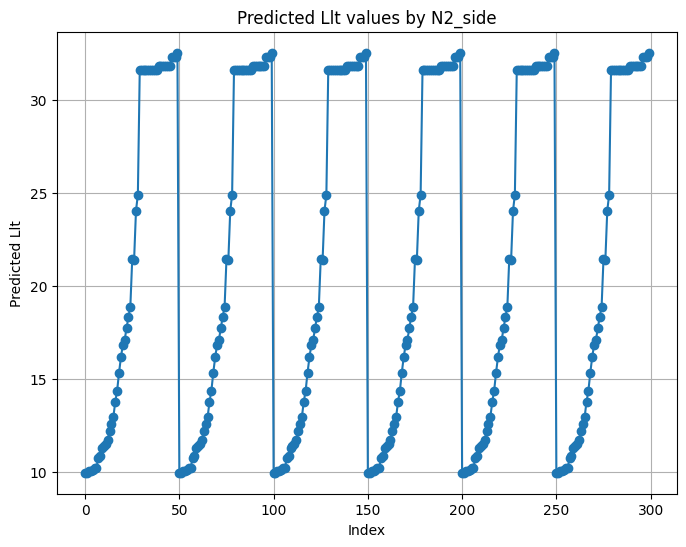

In [34]:


import matplotlib.pyplot as plt

# 예측값 계산
y_pred1 = models["Llt"].predict(df_plus)
# y_pred2 = models["Llt"].predict(df2)

# plot
plt.figure(figsize=(8,6))
plt.plot(range(len(y_pred1)), y_pred1, marker='o')
# plt.plot(range(len(y_pred2)), y_pred2, marker='o')
plt.xlabel("Index")
plt.ylabel("Predicted Llt")
plt.title("Predicted Llt values by N2_side")
plt.grid(True)
plt.show()

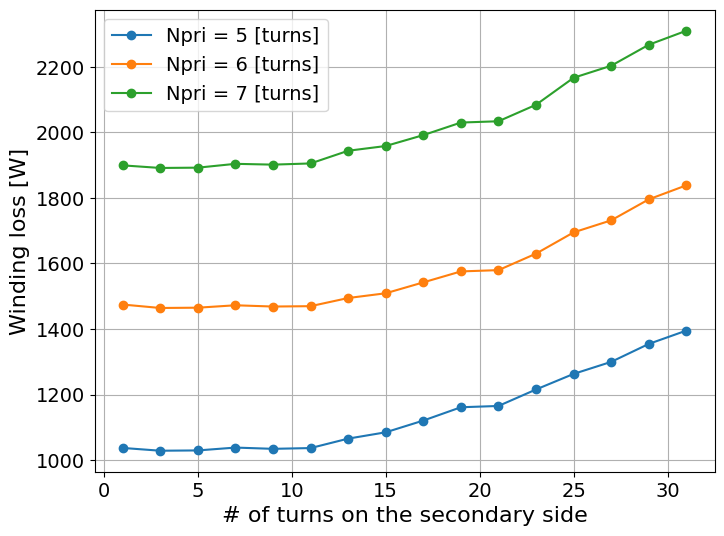

In [54]:
# N1, N2를 둘 다 sweep할 수 있도록 반복문 확장
[w1, l1, l2, h1] = [400, 75, 200, 500]
[w1c_space_x, w1w2_space_x, w2c_space_x] = [20, 20, 20]
[w1c_space_y, w1w2_space_y, w2w2_space_y, w2c_space_y] = [20, 20, 20, 20]
[w1c_space_z, w2c_space_z] = [20, 20]
[window_ratio, wh1, wh2, wff1, wff2] = [0.4, 0.8, 0.8, 1, 0.75]

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

N2 = 50  # N2는 고정
plot_N1_list = [5, 6, 7]  # 이 값들에 대해 그래프를 그릴 것

results_by_N1 = {}

for N1 in plot_N1_list:
    arr = []
    for N2_side in range(1, 32):
        param_list = [
            N1, N2, N2-N2_side, N2_side, w1, l1, l2, h1,
            w1c_space_x, w1w2_space_x, w2c_space_x,
            w1c_space_y, w1w2_space_y, w2w2_space_y, w2c_space_y,
            w1c_space_z, w2c_space_z,
            window_ratio, wh1, wh2, wff1, wff2
        ]
        arr.append(param_list)
    
    result, df_plus = validation_check(arr)
    df_plus = df_plus.drop(columns=['result'])
    
    y_pred = models["Llt"].predict(df_plus)
    y_pred = models["Tx_loss"].predict(df_plus) + models["Rx_loss"].predict(df_plus)
    results_by_N1[N1] = (df_plus['N2_side'].values, y_pred)

# plot
plt.figure(figsize=(8,6))
for N1 in plot_N1_list:
    N2_side_vals, y_pred_vals = results_by_N1[N1]
    # 짝수 인덱스만 플롯
    plt.plot(N2_side_vals[::2], y_pred_vals[::2], marker='o', label=f'N1={N1}턴')

plt.xlabel("# of turns on the secondary side", fontsize=16)
plt.ylabel("Winding loss [W]", fontsize=16)
# plt.title("Predicted Llt values by N2_side (N1=5, 6, 7턴 별)", fontsize=18)
plt.grid(True)
plt.legend(["Npri = 5 [turns]", "Npri = 6 [turns]", "Npri = 7 [turns]"], fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.show()

In [ ]:



def calculate_coil_parameter(N, N_layer, h1, height_ratio, fill_factor):
    height = h1 * height_ratio
    effective_height = height * fill_factor

    if N_layer == 1:
        effective_N = N
    elif N_layer == 2:
        effective_N = math.ceil(N / 2)
    else:
        effective_N = N 

    if effective_N == 0:
        return 0, 0

    coil_diameter = effective_height / (effective_N + 1)
    
    if effective_N > 0:
        coil_z_gap = (height - effective_height) / effective_N
    else:
        coil_z_gap = 0

    return coil_diameter, coil_z_gap



def calculate_coil_offset(h1, height_ratio, offset_ratio) :

    height = h1 * height_ratio
    offset = (h1 - height)/2 * offset_ratio

    return offset


def calculate_coil_offset_sub(h1, height_ratio, offset_ratio_center, offset_ratio_sub) :

    # h1을 그대로 넣을 것

    height = h1/2 * height_ratio
    gap = h1 - 2*height

    center_gap = gap * offset_ratio_center

    if offset_ratio_sub == 0 :
        top_gap = (gap - center_gap)/2
        bottom_gap = (gap - center_gap)/2
    elif offset_ratio_sub > 0 :
        top_gap = (gap - center_gap) * (1-abs(offset_ratio_sub))
        bottom_gap = (gap - center_gap) * abs(offset_ratio_sub)
    elif offset_ratio_sub < 0 : 
        top_gap = (gap - center_gap) * abs(offset_ratio_sub)
        bottom_gap = (gap - center_gap) * (1-abs(offset_ratio_sub))

    offset_pri = h1/4 - top_gap - (h1/4*height_ratio)
    offset_sub = -h1/4 + bottom_gap + (h1/4*height_ratio)

    return top_gap, bottom_gap, offset_pri, offset_sub

def input_processing(input_vector):

    input_vector = np.array(input_vector)

    # N1, N1_layer, N2_layer, per, requency, w1, l1_ref, l1_top_ratio, l1_side_ratio, l2_gap, 
    # h1, N1_height_ratio, N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_l, N2_space_w, N2_space_l, N1_layer_gap, 
    # N2_layer_gap, N1_offset_ratio, N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity, winding_thermal_ratio, 
    # wind_speed

    N1 = input_vector[0]
    N2 = N1
    N1_layer = 1
    N2_layer = 1
    per = input_vector[1]
    frequency = 20

    w1 = input_vector[2] / 10
    l1_ref = input_vector[3] / 10
    l1_top_ratio = input_vector[4] / 100
    l1_side_ratio = input_vector[5] / 100
    l2_gap = input_vector[6] / 10
    h1 = input_vector[7] / 10

    l1_center = 2 * l1_ref
    l1_top = l1_ref * l1_top_ratio
    l1_side = l1_ref * l1_side_ratio

    N1_height_ratio = input_vector[8] / 100
    N1_fill_factor = input_vector[9] / 100
    N2_height_ratio = input_vector[10] / 100
    N2_fill_factor = input_vector[11] / 100

    N1_space_w = input_vector[12] / 10
    N1_space_l = input_vector[13] / 10
    N2_space_w = input_vector[14] / 10
    N2_space_l = input_vector[15] / 10

    N1_offset_ratio = input_vector[16] / 100
    offset_ratio_center = input_vector[17] / 100
    offset_ratio_sub = input_vector[18] / 100

    N1_coil_diameter, N1_coil_zgap = calculate_coil_parameter(N1, N1_layer, h1, N1_height_ratio, N1_fill_factor)
    N2_coil_diameter, N2_coil_zgap = calculate_coil_parameter(N2, N2_layer, h1/2, N2_height_ratio, N2_fill_factor)

    N1_offset = calculate_coil_offset(h1, N1_height_ratio, N1_offset_ratio)
    h1_gap = (h1 - h1*N1_height_ratio)/2 - abs(N1_offset)
    h2_gap, h3_gap, N2_offset, N3_offset = calculate_coil_offset_sub(h1, N2_height_ratio, offset_ratio_center, offset_ratio_sub)

    N1_layer_gap = 5
    N2_layer_gap = 5

    l2_lower = N1_layer*N1_coil_diameter + N2_layer*N2_coil_diameter + (N1_layer-1)*N1_layer_gap + (N2_layer-1)*N2_layer_gap + N1_space_l + N2_space_l
    l2 = l2_lower + l2_gap

    winding_thermal_ratio = input_vector[19] / 100
    core_thermal_ratio = input_vector[20] / 100
    wind_speed = input_vector[21] / 100

    parameter = {
        "N1": N1,
        "N2": N2,
        "N1_layer": N1_layer,
        "N2_layer": N2_layer,

        "frequency": frequency,
        "per": per,

        "w1": w1,
        "l1_top": l1_top,
        "l1_top_ratio": l1_top_ratio,
        "l1_side": l1_side,
        "l1_side_ratio": l1_side_ratio,
        "l1_center": l1_center,
        "l2": l2,
        "l2_gap": l2_gap,
        "h1": h1,
        "h1_gap": h1_gap,
        "h2_gap": h2_gap,
        "h3_gap": h3_gap,

        "N1_height_ratio": N1_height_ratio,
        "N1_fill_factor": N1_fill_factor,
        "N1_coil_diameter": N1_coil_diameter,
        "N1_coil_zgap": N1_coil_zgap,
        "N2_height_ratio": N2_height_ratio,
        "N2_fill_factor": N2_fill_factor,
        "N2_coil_diameter": N2_coil_diameter,
        "N2_coil_zgap": N2_coil_zgap,

        "N1_space_w": N1_space_w,
        "N1_space_l": N1_space_l,
        "N2_space_w": N2_space_w,
        "N2_space_l": N2_space_l,
        "N1_layer_gap": N1_layer_gap,
        "N2_layer_gap": N2_layer_gap,

        "N1_offset_ratio": N1_offset_ratio,
        "offset_ratio_center": offset_ratio_center,
        "offset_ratio_sub": offset_ratio_sub,
        "N1_offset": N1_offset,
        "N2_offset": N2_offset,
        "N3_offset": N3_offset,

        "winding_thermal_ratio": winding_thermal_ratio,
        "core_thermal_ratio": core_thermal_ratio,
        "wind_speed": wind_speed
    }

    return parameter



# roop

import numpy as np
import pandas as pd
import random
import math
import os

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


def compute_efficiency(inp):

    np_inp = np.array(list(inp.values()))

    winding_loss1 = models["P_winding1"].predict([np_inp])[0] * 0.5 * 0.66  # 배열에서 스칼라 값 추출
    Lmt = models["Lmt1"].predict([np_inp])[0]
    V = 750
    Im = V/2/3.141592/30e+3/(Lmt*1e-6)
    winding_loss1 = winding_loss1 * ((487+Im)**2 / (487**2))
    winding_loss2 = models["P_winding2"].predict([np_inp])[0] * 0.5 * 0.66
    winding_loss3 = models["P_winding3"].predict([np_inp])[0] * 0.5 * 0.66

    core_loss = models["P_core"].predict([np_inp])[0]
    total_loss = winding_loss1 + winding_loss2 + winding_loss3 + core_loss
    eff = (350e+3) / (350e+3 + total_loss) * 100

    return eff

def compute_area(inp):

    w1 = inp["w1"]
    l1_top = inp["l1_top"]
    l1_side = inp["l1_side"]
    l1_center = inp["l1_center"]
    l2 = inp["l2"]
    h1 = inp["h1"]

    N1_space_w = inp["N1_space_w"]
    N2_space_w = inp["N2_space_w"]

    N1_coil_diameter = inp["N1_coil_diameter"]
    N2_coil_diameter = inp["N2_coil_diameter"]

    width = w1 + 2*(N1_space_w+N2_space_w) + (2*N1_coil_diameter) + (2*N2_coil_diameter)

    length = l1_center + 2*l1_side + 2*l2
    
    height = 2*l1_top + h1

    area = length * width
    volume = length * width * height

    return width, length, height, area, volume


# ======================================
# 문제 클래스 정의
# ======================================

# N1, N1_layer, N2_layer, per, frequency, w1, l1_ref, l1_top_ratio, l1_side_ratio, l2_gap, 
# h1, N1_height_ratio, N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_l, N2_space_w, N2_space_l, N1_layer_gap, 
# N2_layer_gap, N1_offset_ratio, N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity, winding_thermal_ratio, 
# wind_speed

class TransformerProblem(ElementwiseProblem):
    def __init__(self):
        # DEAP과 동일한 하한/상한 (정수형)
        #xl = np.array([ 4,  5,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0,  0, 100, 100,  20], dtype=int)
        #xu = np.array([10, 10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 50, 500, 400, 200], dtype=int)
        # Define bounds for each parameter
        bounds = {
            "N1": (3, 6),                  # Number of primary turns
            "per": (3000, 3000),            # Permeability         
            "w1": (1000, 3500),             # Width 1
            "l1_ref": (200, 600),           # Length 1 reference
            "l1_top_ratio": (60, 150),      # Top ratio
            "l1_side_ratio": (60, 120),     # Side ratio
            "l2_gap": (50, 500),            # Gap 2
            "h1": (1500, 4000),             # Height 1
            "N1_height_ratio": (50, 95),     # Primary height ratio
            "N1_fill_factor": (70, 95),      # Primary fill factor
            "N2_height_ratio": (70,95),    # Secondary height ratio
            "N2_fill_factor": (70, 95),     # Secondary fill factor
            "N1_space_w": (30, 500),         # Primary space width
            "N1_space_l": (30, 500),         # Primary space length
            "N2_space_w": (30, 500),         # Secondary space width
            "N2_space_l": (30, 500),         # Secondary space length
            "N1_offset_ratio": (-80, 80),     # Primary offset ratio
            "offset_ratio_center": (5, 95),     # Secondary offset ratio
            "offset_ratio_sub": (-95, 95),     # Secondary offset ratio
            "winding_thermal_ratio": (33, 33), # Winding thermal ratio
            "core_thermal_ratio": (100, 100), # Core thermal ratio
            "wind_speed": (30, 30)           # Wind speed
        }

        xl = np.array([v[0] for v in bounds.values()], dtype=int)
        xu = np.array([v[1] for v in bounds.values()], dtype=int)
        # 제약식이 11개이므로 n_ieq_constr=11
        super().__init__(n_var=len(bounds),
                         n_obj=2,
                         n_ieq_constr=29,
                         xl=xl,
                         xu=xu,
                         type_var=int)

    def _evaluate(self, x, out, *args, **kwargs):
        # x는 정수 배열 [x1, x2, ..., x14]
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))

        # 목적 함수 계산
        width, length, height, area, volume = compute_area(inp)
        f1 = volume
        f2 = compute_efficiency(inp)
        

        # 제약식 g_i(x) ≤ 0 으로 변환
        g = []
        early_stop = False

        e_Llk_p = 0
        e_Llk_n = 0.03
        e_Llk = 0.03

        # e_Llk_p = 1.0
        # e_Llk_n = 1.0
        # e_Llk = 1.0

        Llk12 = models["Llk12"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
        Llk13 = models["Llk13"].predict([np_inp])[0]
        Llk23 = models["Llk23"].predict([np_inp])[0]
        Llk32 = models["Llk32"].predict([np_inp])[0]

        weight_Llk = 1

        Llk1 = ((Llk12+Llk13) - (Llk23+Llk32)/2) / 2
        Llk2 = Llk12 - Llk1
        Llk3 = Llk13 - Llk1



        # g.append((13.54*(1-e_Llk_n) - Llk12)/13.54*weight_Llk) # min 
        # g.append((Llk12 - 13.54*(1+e_Llk_p))/13.54*weight_Llk) # max
        # g.append((13.54*(1-e_Llk_n) - Llk13)/13.54*weight_Llk)
        # g.append((Llk13 - 13.54*(1+e_Llk_p))/13.54*weight_Llk)
        # g.append((20*(1-e_Llk) - Llk23)/20*weight_Llk)
        # g.append((Llk23 - 20*(1+e_Llk))/20*weight_Llk)
        # g.append((20*(1-e_Llk) - Llk32)/20*weight_Llk)
        # g.append((Llk32 - 20*(1+e_Llk))/20*weight_Llk)


        g.append((3.54*(1-e_Llk) - Llk1)/3.54*weight_Llk) # min 
        g.append((Llk1 - 3.54*(1+e_Llk_p))/3.54*weight_Llk) # max
        g.append((10*(1-e_Llk) - Llk2)/10*weight_Llk) # min 
        g.append((Llk2 - 10*(1+e_Llk_p))/10*weight_Llk) # max
        g.append((10*(1-e_Llk) - Llk3)/10*weight_Llk) # min 
        g.append((Llk3 - 10*(1+e_Llk_p))/10*weight_Llk) # max




        temp_max_leg_center = models["Temp_max_leg_center"].predict([np_inp])[0]
        temp_max_leg_left = models["Temp_max_leg_left"].predict([np_inp])[0]
        temp_max_leg_right = models["Temp_max_leg_right"].predict([np_inp])[0]
        temp_max_leg_top_left = models["Temp_max_leg_top_left"].predict([np_inp])[0]
        temp_max_leg_top_right = models["Temp_max_leg_top_right"].predict([np_inp])[0]
        temp_max_leg_bottom_left = models["Temp_max_leg_bottom_left"].predict([np_inp])[0]
        temp_max_leg_bottom_right = models["Temp_max_leg_bottom_right"].predict([np_inp])[0]

        temp_max_winding1 = models["Temp_max_winding1"].predict([np_inp])[0]
        temp_max_winding2 = models["Temp_max_winding2"].predict([np_inp])[0]
        temp_max_winding3 = models["Temp_max_winding3"].predict([np_inp])[0]
        temp_mean_winding1 = models["Temp_mean_winding1"].predict([np_inp])[0]
        temp_mean_winding2 = models["Temp_mean_winding2"].predict([np_inp])[0]
        temp_mean_winding3 = models["Temp_mean_winding3"].predict([np_inp])[0]
        
        core_temp_max = 120
        g.append((temp_max_leg_center - core_temp_max)/core_temp_max) # 7
        g.append((temp_max_leg_left - core_temp_max)/core_temp_max) # 8
        g.append((temp_max_leg_right - core_temp_max)/core_temp_max) # 9
        g.append((temp_max_leg_top_left - core_temp_max)/core_temp_max) # 10
        g.append((temp_max_leg_top_right - core_temp_max)/core_temp_max) # 11
        g.append((temp_max_leg_bottom_left - core_temp_max)/core_temp_max) # 12
        g.append((temp_max_leg_bottom_right - core_temp_max)/core_temp_max) # 13

        winding_temp_max = 120*1
        winding_temp_mean = 120/1.25
        g.append((temp_max_winding1 - winding_temp_max)/winding_temp_max) # 14
        g.append((temp_max_winding2 - winding_temp_max)/winding_temp_max) # 15
        g.append((temp_max_winding3 - winding_temp_max)/winding_temp_max) # 16
        g.append((temp_mean_winding1 - winding_temp_mean)/winding_temp_mean) # 17
        g.append((temp_mean_winding2 - winding_temp_mean)/winding_temp_mean) # 18
        g.append((temp_mean_winding3 - winding_temp_mean)/winding_temp_mean) # 19

        
        B_mean_leg_center = models["B_mean_leg_center"].predict([np_inp])[0]
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]
        B_mean_leg_top_left = models["B_mean_leg_top_left"].predict([np_inp])[0]
        B_mean_leg_top_right = models["B_mean_leg_top_right"].predict([np_inp])[0]
        B_mean_leg_bottom_left = models["B_mean_leg_bottom_left"].predict([np_inp])[0]
        B_mean_leg_bottom_right = models["B_mean_leg_bottom_right"].predict([np_inp])[0]



        g.append((B_mean_leg_center - 0.25)/0.25) # 20
        g.append((B_mean_leg_left - 0.25)/0.25) # 21
        g.append((B_mean_leg_right - 0.25)/0.25) # 22
        g.append((B_mean_leg_top_left - 0.25)/0.25) # 23
        g.append((B_mean_leg_top_right - 0.25)/0.25) # 24
        g.append((B_mean_leg_bottom_left - 0.25)/0.25) # 25
        g.append((B_mean_leg_bottom_right - 0.25)/0.25) # 26


        g.append((height - 500)/500) # 27
        g.append((length - 400)/400) # 28
        g.append((width - 400)/400) # 29


 



        out["F"] = np.array([f1, -f2])  # numpy 배열로 변환
        out["G"] = np.array(g, dtype=float)





def build_df_from_result(res, seed):
    pareto_X = res.X.astype(int)
    rows = []
    for x in pareto_X:
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))
        width, length, height, area, volume = compute_area(inp)
        winding_loss1 = models["P_winding1"].predict([np_inp])[0] * inp["winding_thermal_ratio"]

        V = 750
        Lmt1 = models["Lmt1"].predict([np_inp])[0]
        Im = V/2/3.141592/30e+3/(Lmt1*1e-6)

        winding_loss1_600 = winding_loss1 * ((487+Im)**2 / (487**2)) 
        winding_loss2 = models["P_winding2"].predict([np_inp])[0] * inp["winding_thermal_ratio"]
        winding_loss3 = models["P_winding3"].predict([np_inp])[0] * inp["winding_thermal_ratio"]
        core_loss = models["P_core"].predict([np_inp])[0] * inp["core_thermal_ratio"]
        total_loss = winding_loss1 + winding_loss2 + winding_loss3 + core_loss
        total_loss_600 = winding_loss1_600 + winding_loss2 + winding_loss3 + core_loss
        eff = (350e+3) / (350e+3 + total_loss) 
        eff_600 = (350e+3) / (350e+3 + total_loss_600) 

        Llk12 = models["Llk12"].predict([np_inp])[0]
        Llk13 = models["Llk13"].predict([np_inp])[0]
        Llk23 = models["Llk23"].predict([np_inp])[0]
        Llk32 = models["Llk32"].predict([np_inp])[0]

        temp_max_leg_center = models["Temp_max_leg_center"].predict([np_inp])[0]
        temp_max_leg_left = models["Temp_max_leg_left"].predict([np_inp])[0]
        temp_max_leg_right = models["Temp_max_leg_right"].predict([np_inp])[0]
        temp_max_leg_top_left = models["Temp_max_leg_top_left"].predict([np_inp])[0]
        temp_max_leg_top_right = models["Temp_max_leg_top_right"].predict([np_inp])[0]
        temp_max_leg_bottom_left = models["Temp_max_leg_bottom_left"].predict([np_inp])[0]
        temp_max_leg_bottom_right = models["Temp_max_leg_bottom_right"].predict([np_inp])[0]

        temp_max_winding1 = models["Temp_max_winding1"].predict([np_inp])[0]
        temp_max_winding2 = models["Temp_max_winding2"].predict([np_inp])[0]
        temp_max_winding3 = models["Temp_max_winding3"].predict([np_inp])[0]
        temp_mean_winding1 = models["Temp_mean_winding1"].predict([np_inp])[0]
        temp_mean_winding2 = models["Temp_mean_winding2"].predict([np_inp])[0]
        temp_mean_winding3 = models["Temp_mean_winding3"].predict([np_inp])[0]
        
        B_mean_leg_center = models["B_mean_leg_center"].predict([np_inp])[0]
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]
        B_mean_leg_top_left = models["B_mean_leg_top_left"].predict([np_inp])[0]
        B_mean_leg_top_right = models["B_mean_leg_top_right"].predict([np_inp])[0]
        B_mean_leg_bottom_left = models["B_mean_leg_bottom_left"].predict([np_inp])[0]
        B_mean_leg_bottom_right = models["B_mean_leg_bottom_right"].predict([np_inp])[0]


        row = dict(zip(feature_names, np_inp))
        row.update({
            "area": area / 100,  # mm^2 to cm^2
            "volume": volume / 1e6,  # mm^3 to L
            "eff": eff,
            "eff_600": eff_600,
            "width": width,
            "length": length,
            "height": height,
            "Lmt1": Lmt1,
            "Llk12": Llk12,
            "Llk13": Llk13,
            "Llk23": Llk23,
            "Llk32": Llk32,
            "winding_loss1": winding_loss1,
            "winding_loss1_600": winding_loss1_600,
            "winding_loss2": winding_loss2,
            "winding_loss3": winding_loss3,
            "core_loss": core_loss,
            "total_loss": total_loss,
            "total_loss_600": total_loss_600,
            "temp_max_leg_center": temp_max_leg_center,
            "temp_max_leg_left": temp_max_leg_left,
            "temp_max_leg_right": temp_max_leg_right,
            "temp_max_leg_top_left": temp_max_leg_top_left,
            "temp_max_leg_top_right": temp_max_leg_top_right,
            "temp_max_leg_bottom_left": temp_max_leg_bottom_left,
            "temp_max_leg_bottom_right": temp_max_leg_bottom_right,
            "temp_max_winding1": temp_max_winding1,
            "temp_max_winding2": temp_max_winding2,
            "temp_max_winding3": temp_max_winding3,
            "temp_mean_winding1": temp_mean_winding1,
            "temp_mean_winding2": temp_mean_winding2,
            "temp_mean_winding3": temp_mean_winding3,
            "B_mean_leg_center": B_mean_leg_center,
            "B_mean_leg_left": B_mean_leg_left,
            "B_mean_leg_right": B_mean_leg_right,
            "B_mean_leg_top_left": B_mean_leg_top_left,
            "B_mean_leg_top_right": B_mean_leg_top_right,
            "B_mean_leg_bottom_left": B_mean_leg_bottom_left,
            "B_mean_leg_bottom_right": B_mean_leg_bottom_right,
            "seed": seed
        })
        rows.append(row)

    return pd.DataFrame(rows)


# ======================================
# 메인 실행부
# ======================================
MU, NGEN = 100, 500
CXPB, MUTPB = 0.7, 0.3
NUM_ITRS = 10

feature_names = [
            "N1", "N2", "N1_layer", "N2_layer", "frequency", "per", "w1", "l1_top", "l1_top_ratio", "l1_side", "l1_side_ratio", "l1_center", "l2", "l2_gap", "h1",
            "h1_gap", "h2_gap", "h3_gap", "N1_height_ratio", "N1_fill_factor", "N1_coil_diameter",
            "N1_coil_zgap", "N2_height_ratio", "N2_fill_factor", "N2_coil_diameter",
            "N2_coil_zgap", "N1_space_w", "N1_space_l", "N2_space_w", "N2_space_l", "N1_layer_gap",
            "N2_layer_gap", "N1_offset_ratio", "offset_ratio_center", "offset_ratio_sub",
            "N1_offset", "N2_offset", "N3_offset", "winding_thermal_ratio", "core_thermal_ratio", "wind_speed"
        ]

# 이전 결과 파일이 있으면 로드
pareto_file = 'pareto_front_test.csv'
if os.path.exists(pareto_file):
    previous_pareto = pd.read_csv(pareto_file)
else:
    previous_pareto = pd.DataFrame()


all_results = []


for itr in range(NUM_ITRS):
    print(f"Running NSGA-II {itr+1} / {NUM_ITRS}")
    seed = np.random.randint(0, 1000000)
    from pymoo.core.callback import Callback

    # ======================================
    # Call back
    # ======================================
    class ConstraintCallback(Callback):
        def __init__(self):
            super().__init__()
            self.constraint_history = []
            self.design_itr = []
            self.last_design = []
            
        def notify(self, algorithm):
            G = algorithm.pop.get("G")  # (pop_size, n_constr)
            avg_violation = np.mean(np.maximum(G, 0), axis=0)
            self.constraint_history.append(avg_violation)
            self.design_itr.append(algorithm.pop.get("X")[0,:])
            self.last_design = algorithm.pop.get("X")



    cb = ConstraintCallback()

    # ======================================
    # 실행 함수 정의
    # ======================================
    def run_nsga2(seed):
        np.random.seed(seed)
        random.seed(seed)

        algorithm = NSGA2(
            pop_size=MU,
            sampling=IntegerRandomSampling(),
            crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
            mutation=PM(eta=20, repair=RoundingRepair()),
            eliminate_duplicates=True
        )

        return minimize(
            problem=TransformerProblem(),
            algorithm=algorithm,
            termination=('n_gen', NGEN),
            seed=seed,
            callback=cb,
            verbose=True
        )


    res = run_nsga2(seed)
    
    
    try:

        constraint_history = np.array(cb.constraint_history)  # (n_gen, n_constr)
        fig, ax = plt.subplots(figsize=(14, 6))
        offset = 0  # x좌표 간격
        for i in range(constraint_history.shape[1]):
            y = constraint_history[:, i]
            ax.plot(range(len(y)), y, label=f"Constraint {i+1}")
            
            # 제약 번호 표시 (겹치지 않게 x좌표에 오프셋 적용)
            ax.text(len(y)-1 + (i - constraint_history.shape[1]/2) * offset, 
                    y[-1], f"{i+1}", fontsize=15, 
                    color=ax.lines[-1].get_color())
        ax.set_xlabel("Generation")
        ax.set_ylabel("Average Constraint Violation")
        ax.set_title("Constraint Violations Over Generations")
        plt.show()   


        df = build_df_from_result(res, seed)
        
        if df is not None:
            all_results.append(df)
            
            # 현재까지의 결과와 이전 파레토 프론트 결합
            df_current = pd.concat(all_results + [previous_pareto], ignore_index=True)
            F = df_current[["volume", "eff"]].to_numpy()
            F[:, 1] = -F[:, 1]  # 효율 최대화 → 부호 반전

            # Non-dominated sorting
            nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
            df_pareto = df_current.iloc[nds].copy()
            df_pareto["eff"] = -F[nds, 1]  # 다시 양수로 되돌리기
            df_pareto = df_pareto.sort_values(by="eff", ascending=False).reset_index(drop=True)
            
            # 현재 파레토 프론트 저장
            df_pareto.to_csv(pareto_file, index=False)
            
            # 루프 카운터 파일 로드 또는 생성
            loop_counter_file = 'loop_counter_test.txt'
            if os.path.exists(loop_counter_file):
                with open(loop_counter_file, 'r') as f:
                    loop_counter = int(f.read().strip())
            else:
                loop_counter = 0

            
            # 루프 카운터 증가 및 저장 
            loop_counter += 1
            with open(loop_counter_file, 'w') as f:
                f.write(str(loop_counter))
            

            backup_file = f'pareto_front_test_{loop_counter}.csv'
            df_pareto.to_csv(backup_file, index=False)
            print(f"Backup created: {backup_file}")
                
            print(f"Iteration {itr+1} Pareto front saved (Total loops: {loop_counter})")



    except AttributeError as e:
        print(f"Iteration {itr+1} failed: {str(e)}")
        continue
    except Exception as e:
        print(f"Unexpected error in iteration {itr+1}: {str(e)}")
        print(f"Error occurred at line {e.__traceback__.tb_lineno}")
        print(f"Error code: {e.args[0]}")
        print(f"Error line code: {e.__traceback__.tb_frame.f_code.co_name}")
        continue

# 최종 결과 출력
if 'df_pareto' in locals():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("Final Pareto front:")
    print(df_pareto)
else:
    print("No valid results found")


Running NSGA-II 1 / 10
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  1.0543058198 |  5.5128952741 |             - |             -
     2 |      200 |      1 |  0.9738205134 |  2.0274022348 |             - |             -
     3 |      300 |      1 |  0.6555734576 |  1.4449423608 |             - |             -
     4 |      400 |      1 |  0.5358139685 |  1.1386428647 |             - |             -
     5 |      500 |      1 |  0.4291723381 |  0.9552720539 |             - |             -
     6 |      600 |      1 |  0.4291723381 |  0.7910145556 |             - |             -
     7 |      700 |      1 |  0.4291723381 |  0.6258093342 |             - |             -
     8 |      800 |      1 |  0.3758873530 |  0.5367079790 |             - |             -
     9 |      900 |      1 |  0.3612109146 |  0.4831861932 |             - |             -
    10 |     1000 |      1 |  0.3107557161 |  0.4438665304 |       

In [ ]:
import as plt

In [23]:
cb.constraint_history[-1]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.13279421e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.44090463e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [ ]:
import numpy as np
import math


def calculate_coil_parameter(N, h1, height_ratio, fill_factor):
    height = h1 * height_ratio
    effective_height = height * fill_factor

    effective_N = N 

    if effective_N == 0:
        return 0, 0

    coil_diameter = effective_height / (effective_N + 1)
    
    if effective_N > 0:
        coil_z_gap = (height - effective_height) / effective_N
    else:
        coil_z_gap = 0

    return coil_diameter, coil_z_gap



def calculate_coil_offset(h1, height_ratio, offset_ratio) :

    height = h1 * height_ratio
    offset = (h1 - height)/2 * offset_ratio

    return offset


def input_processing(input_vector):

    input_vector = np.array(input_vector)

    # N1, N1_layer, N2_layer, per, requency, w1, l1_ref, l1_top_ratio, l1_side_ratio, l2_gap, 
    # h1, N1_height_ratio, N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_l, N2_space_w, N2_space_l, N1_layer_gap, 
    # N2_layer_gap, N1_offset_ratio, N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity, winding_thermal_ratio, 
    # wind_speed

    N1 = input_vector[0]
    per = input_vector[1]
    

    w1 = input_vector[2] / 10
    l1_ref = input_vector[3] / 10
    l1_top_ratio = input_vector[4] / 100
    l1_side_ratio = input_vector[5] / 100
    l2_gap = input_vector[6] / 10
    h1 = input_vector[7] / 10

    l1_center = 2 * l1_ref
    l1_top = l1_ref * l1_top_ratio
    l1_side = l1_ref * l1_side_ratio

    N1_height_ratio = input_vector[8] / 100
    N1_fill_factor = input_vector[9] / 100
    N2_height_ratio = input_vector[10] / 100
    N2_fill_factor = input_vector[11] / 100

    N1_space_w = input_vector[12] / 10
    N1_space_l = input_vector[13] / 10
    N2_space_w = input_vector[14] / 10
    N2_space_l = input_vector[15] / 10

    N1_offset_ratio = input_vector[16] / 100
    N2_offset_ratio = input_vector[17] / 100
    N3_offset_ratio = input_vector[18] / 100

    N1_coil_diameter, N1_coil_zgap = calculate_coil_parameter(N1, h1, N1_height_ratio, N1_fill_factor)
    N2_coil_diameter, N2_coil_zgap = calculate_coil_parameter(N1, h1/2, N2_height_ratio, N2_fill_factor)

    N1_offset = calculate_coil_offset(h1, N1_height_ratio, N1_offset_ratio)
    N2_offset = calculate_coil_offset(h1/2, N2_height_ratio, N2_offset_ratio)
    N3_offset = calculate_coil_offset(h1/2, N2_height_ratio, N3_offset_ratio)

    h1_gap = (h1 - h1*N1_height_ratio)/2 - abs(N1_offset)
    h2_gap = (h1 - h1*N2_height_ratio)/2 - abs(N2_offset)

    l2_lower = N1_coil_diameter + N2_coil_diameter + N1_space_l + N2_space_l
    l2 = l2_lower + l2_gap

    winding_thermal_ratio = input_vector[19] / 100
    core_thermal_ratio = input_vector[20] / 100
    wind_speed = input_vector[21] / 100

    parameter = {
        "N1": N1,

        "per": per,
        
        "w1": w1,
        "l1_top": l1_top,
        "l1_top_ratio": l1_top_ratio,
        "l1_side": l1_side,
        "l1_side_ratio": l1_side_ratio,
        "l1_center": l1_center,

        "l2": l2,
        "l2_gap": l2_gap,
        "h1": h1,
        "h1_gap": h1_gap,
        "h2_gap": h2_gap,

        "N1_height_ratio": N1_height_ratio,
        "N1_fill_factor": N1_fill_factor,
        "N1_coil_diameter": N1_coil_diameter,
        "N1_coil_zgap": N1_coil_zgap,
        "N2_height_ratio": N2_height_ratio,
        "N2_fill_factor": N2_fill_factor,
        "N2_coil_diameter": N2_coil_diameter,
        "N2_coil_zgap": N2_coil_zgap,

        "N1_layer_gap" : 5,
        "N2_layer_gap" : 5,

        "N1_space_w": N1_space_w,
        "N1_space_l": N1_space_l,
        "N2_space_w": N2_space_w,
        "N2_space_l": N2_space_l,

        "N1_offset_ratio": N1_offset_ratio,
        "N2_offset_ratio": N2_offset_ratio,
        "N3_offset_ratio": N3_offset_ratio,

        "N1_offset": N1_offset,
        "N2_offset": N2_offset,
        "N3_offset": N3_offset,

        "winding_thermal_ratio": winding_thermal_ratio,
        "core_thermal_ratio": core_thermal_ratio,
        "wind_speed": wind_speed
    }

    return parameter


In [ ]:
# roop

import numpy as np
import pandas as pd
import random
import math
import os

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


def compute_efficiency(inp):

    np_inp = np.array(list(inp.values()))

    winding_loss1 = models["P_winding1"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
    Lmt = models["Lmt1"].predict([np_inp])[0]
    V = 750
    Im = V/2/3.141592/30e+3/(Lmt*1e-6)
    winding_loss1 = winding_loss1 * ((600+Im)**2 / (600**2))


    winding_loss2 = models["P_winding2"].predict([np_inp])[0]
    winding_loss3 = models["P_winding3"].predict([np_inp])[0]
    core_loss = models["P_core"].predict([np_inp])[0]
    total_loss = winding_loss1 + winding_loss2 + winding_loss3 + core_loss
    eff = (350e+3) / (350e+3 + total_loss) * 100

    return eff

def compute_area(inp):

    w1 = inp["w1"]
    l1_top = inp["l1_top"]
    l1_side = inp["l1_side"]
    l1_center = inp["l1_center"]
    l2 = inp["l2"]
    h1 = inp["h1"]

    N1_space_w = inp["N1_space_w"]
    N2_space_w = inp["N2_space_w"]

    N1_coil_diameter = inp["N1_coil_diameter"]
    N2_coil_diameter = inp["N2_coil_diameter"]

    width = w1 + 2*(N1_space_w+N2_space_w) + (2*N1_coil_diameter) + (2*N2_coil_diameter)

    length = l1_center + 2*l1_side + 2*l2
    
    height = 2*l1_top + h1

    area = length * width
    volume = length * width * height

    return width, length, height, area, volume


# ======================================
# 문제 클래스 정의
# ======================================

# N1, N1_layer, N2_layer, per, frequency, w1, l1_ref, l1_top_ratio, l1_side_ratio, l2_gap, 
# h1, N1_height_ratio, N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_l, N2_space_w, N2_space_l, N1_layer_gap, 
# N2_layer_gap, N1_offset_ratio, N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity, winding_thermal_ratio, 
# wind_speed

class TransformerProblem(ElementwiseProblem):
    def __init__(self):
        # DEAP과 동일한 하한/상한 (정수형)
        #xl = np.array([ 4,  5,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0,  0, 100, 100,  20], dtype=int)
        #xu = np.array([10, 10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 50, 500, 400, 200], dtype=int)
        # Define bounds for each parameter
        bounds = {
            "N1": (3, 6),                  # Number of primary turns
            "per": (3000, 3000),            # Permeability         
            "w1": (1000, 2000),             # Width 1
            "l1_ref": (200, 500),           # Length 1 reference
            "l1_top_ratio": (60, 120),      # Top ratio
            "l1_side_ratio": (60, 120),     # Side ratio
            "l2_gap": (50, 500),            # Gap 2
            "h1": (1500, 4000),             # Height 1
            "N1_height_ratio": (50, 95),     # Primary height ratio
            "N1_fill_factor": (70, 95),      # Primary fill factor
            "N2_height_ratio": (50,95),    # Secondary height ratio
            "N2_fill_factor": (70, 95),     # Secondary fill factor
            "N1_space_w": (50, 500),         # Primary space width
            "N1_space_l": (50, 500),         # Primary space length
            "N2_space_w": (50, 500),         # Secondary space width
            "N2_space_l": (50, 500),         # Secondary space length
            "N1_offset_ratio": (-80, 80),     # Primary offset ratio
            "N2_offset_ratio": (-80, 80),     # Secondary offset ratio
            "N3_offset_ratio": (-80, 80),     # Secondary offset ratio
            "winding_thermal_ratio": (50, 50), # Winding thermal ratio
            "core_thermal_ratio": (50, 50), # Core thermal ratio
            "wind_speed": (50, 50)           # Wind speed
        }

        xl = np.array([v[0] for v in bounds.values()], dtype=int)
        xu = np.array([v[1] for v in bounds.values()], dtype=int)
        # 제약식이 11개이므로 n_ieq_constr=11
        super().__init__(n_var=len(bounds),
                         n_obj=2,
                         n_ieq_constr=25,
                         xl=xl,
                         xu=xu,
                         type_var=int)

    def _evaluate(self, x, out, *args, **kwargs):
        # x는 정수 배열 [x1, x2, ..., x14]
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))

        # 목적 함수 계산
        width, length, height, area, volume = compute_area(inp)
        f1 = length
        f2 = compute_efficiency(inp)
        

        # 제약식 g_i(x) ≤ 0 으로 변환
        g = []
        early_stop = False

        e_Llk = 0.03
        Llk12 = models["Llk12"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
        Llk13 = models["Llk13"].predict([np_inp])[0]
        Llk23 = models["Llk23"].predict([np_inp])[0]
        Llk32 = models["Llk32"].predict([np_inp])[0]

        weight_Llk = 1


        # g.append((2 - (Llk12 - Llk23/2)) / 3)
        # g.append((2 - (Llk12 - Llk32/2)) / 3)
        # g.append((2 - (Llk13 - Llk23/2)) / 3)
        # g.append((2 - (Llk13 - Llk32/2)) / 3)
        # g.append(((Llk12 - Llk23/2) - 4) / 3)
        # g.append(((Llk12 - Llk32/2) - 4) / 3)
        # g.append(((Llk13 - Llk23/2) - 4) / 3)
        # g.append(((Llk13 - Llk32/2) - 4) / 3)
        
        # g.append((9 - (Llk23)/2) / 10)
        # g.append((9 - (Llk32)/2) / 10)
        # g.append(((Llk23) - 11) / 10)
        # g.append(((Llk32) - 11) / 10)


        g.append((13*(1-e_Llk) - Llk12)/13*weight_Llk)
        g.append((Llk12 - 13*(1+e_Llk))/13*weight_Llk)
        g.append((13*(1-e_Llk) - Llk13)/13*weight_Llk)
        g.append((Llk13 - 13*(1+e_Llk))/13*weight_Llk)
        g.append((20*(1-e_Llk) - Llk23)/20*weight_Llk)
        g.append((Llk23 - 20*(1+e_Llk))/20*weight_Llk)
        g.append((20*(1-e_Llk) - Llk32)/20*weight_Llk)
        g.append((Llk32 - 20*(1+e_Llk))/20*weight_Llk)

        # g.append(33*(1-e_Llk) - (Llk12 + Llk23)*weight_Llk)
        # g.append((Llk12 + Llk23) - 33*(1+e_Llk)*weight_Llk)
        # g.append(33*(1-e_Llk) - (Llk12 + Llk32)*weight_Llk)
        # g.append((Llk12 + Llk32) - 33*(1+e_Llk)*weight_Llk)
        # g.append(33*(1-e_Llk) - (Llk13 + Llk23)*weight_Llk)
        # g.append((Llk13 + Llk23) - 33*(1+e_Llk)*weight_Llk)
        # g.append(33*(1-e_Llk) - (Llk13 + Llk32)*weight_Llk)
        # g.append((Llk13 + Llk32) - 33*(1+e_Llk)*weight_Llk)

        # g.append((2 - (Llk12 - Llk23/2))/3 * 1000)
        # g.append((2 - (Llk12 - Llk32/2))/3 * 1000)
        # g.append((2 - (Llk13 - Llk23/2))/3 * 1000)
        # g.append((2 - (Llk13 - Llk32/2))/3 * 1000)
        # g.append(((Llk12 - Llk23/2)-4)/3 * 1000)
        # g.append(((Llk12 - Llk32/2)-4)/3 * 1000)
        # g.append(((Llk13 - Llk23/2)-4)/3 * 1000)
        # g.append(((Llk13 - Llk32/2)-4)/3 * 1000)

        # g.append((9 - (Llk23)/2)/10 * 100)
        # g.append((9 - (Llk32)/2)/10 * 100)
        # g.append(((Llk23)-11)/10 * 100)
        # g.append(((Llk32)-11)/10 * 100)



        temp_max_core = models["Temp_max_core"].predict([np_inp])[0]
        temp_max_winding = models["Temp_max_winding1"].predict([np_inp])[0]
        temp_max_winding2 = models["Temp_max_winding2"].predict([np_inp])[0]
        temp_max_winding3 = models["Temp_max_winding3"].predict([np_inp])[0]
        temp_mean_winding1 = models["Temp_mean_winding1"].predict([np_inp])[0]
        temp_mean_winding2 = models["Temp_mean_winding2"].predict([np_inp])[0]
        temp_mean_winding3 = models["Temp_mean_winding3"].predict([np_inp])[0]
        
        temp_max = 150
        g.append((temp_max_core - 125)/125)
        g.append((temp_max_winding - 180)/155)
        g.append((temp_max_winding2 - 180)/155)  
        g.append((temp_max_winding3 - 180)/155)   
        g.append((temp_mean_winding1 - 500)/100)
        g.append((temp_mean_winding2 - 500)/100)
        g.append((temp_mean_winding3 - 500)/100)

        
    
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]
        B_mean_leg_center = models["B_mean_leg_center"].predict([np_inp])[0]
        B_mean_leg_top_left = models["B_mean_leg_top_left"].predict([np_inp])[0]
        B_mean_leg_top_right = models["B_mean_leg_top_right"].predict([np_inp])[0]
        B_mean_leg_bottom_left = models["B_mean_leg_bottom_left"].predict([np_inp])[0]
        B_mean_leg_bottom_right = models["B_mean_leg_bottom_right"].predict([np_inp])[0]

        g.append((B_mean_leg_left - 0.25)/0.25)     
        g.append((B_mean_leg_right - 0.25)/0.25)
        g.append((B_mean_leg_center - 0.25)/0.25)
        g.append((B_mean_leg_top_left - 0.25)/0.25)
        g.append((B_mean_leg_top_right - 0.25)/0.25)
        g.append((B_mean_leg_bottom_left - 0.25)/0.25)
        g.append((B_mean_leg_bottom_right - 0.25)/0.25)


        g.append((height - 500)/500)
        g.append((length - 300)/300)
        g.append((width - 300)/300)


        # print(g)


        # g.append((25 - inp["l1_side"])/25)



        out["F"] = np.array([f1, -f2])  # numpy 배열로 변환
        out["G"] = np.array(g, dtype=float)


# ======================================
# 실행 함수 정의
# ======================================
def run_nsga2(seed):
    np.random.seed(seed)
    random.seed(seed)

    algorithm = NSGA2(
        pop_size=MU,
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
        mutation=PM(eta=20, repair=RoundingRepair()),
        eliminate_duplicates=True
    )

    return minimize(
        problem=TransformerProblem(),
        algorithm=algorithm,
        termination=('n_gen', NGEN),
        seed=seed,
        verbose=True
    )


def build_df_from_result(res, seed):
    pareto_X = res.X.astype(int)
    rows = []
    for x in pareto_X:
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))
        width, length, height, area, volume = compute_area(inp)
        winding_loss1 = models["P_winding1"].predict([np_inp])[0] * inp["winding_thermal_ratio"]

        V = 750
        Lmt1 = models["Lmt1"].predict([np_inp])[0]
        Lmt2 = models["Lmt2"].predict([np_inp])[0]
        Im = V/2/3.141592/30e+3/(Lmt1*1e-6)

        winding_loss1_600 = winding_loss1 * ((600+Im)**2 / (600**2)) 
        winding_loss2 = models["P_winding2"].predict([np_inp])[0] * inp["winding_thermal_ratio"]
        winding_loss3 = models["P_winding3"].predict([np_inp])[0] * inp["winding_thermal_ratio"]
        core_loss = models["P_core"].predict([np_inp])[0] * inp["core_thermal_ratio"]
        total_loss = winding_loss1 + winding_loss2 + winding_loss3 + core_loss
        total_loss_600 = winding_loss1_600 + winding_loss2 + winding_loss3 + core_loss
        eff = (350e+3) / (350e+3 + total_loss) 
        eff_600 = (350e+3) / (350e+3 + total_loss_600) 
        
        Llk12 = models["Llk12"].predict([np_inp])[0]
        Llk13 = models["Llk13"].predict([np_inp])[0]
        Llk23 = models["Llk23"].predict([np_inp])[0]
        Llk32 = models["Llk32"].predict([np_inp])[0]


        temp_max_core = models["Temp_max_core"].predict([np_inp])[0]
        temp_max_winding1 = models["Temp_max_winding1"].predict([np_inp])[0]
        temp_max_winding2 = models["Temp_max_winding2"].predict([np_inp])[0]
        temp_max_winding3 = models["Temp_max_winding3"].predict([np_inp])[0]
        temp_mean_winding1 = models["Temp_mean_winding1"].predict([np_inp])[0]
        temp_mean_winding2 = models["Temp_mean_winding2"].predict([np_inp])[0]
        temp_mean_winding3 = models["Temp_mean_winding3"].predict([np_inp])[0]

        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]
        B_mean_leg_center = models["B_mean_leg_center"].predict([np_inp])[0]
        B_mean_leg_top_left = models["B_mean_leg_top_left"].predict([np_inp])[0]
        B_mean_leg_top_right = models["B_mean_leg_top_right"].predict([np_inp])[0]
        B_mean_leg_bottom_left = models["B_mean_leg_bottom_left"].predict([np_inp])[0]
        B_mean_leg_bottom_right = models["B_mean_leg_bottom_right"].predict([np_inp])[0]

        row = dict(zip(feature_names, np_inp))
        row.update({
            "area": area / 100,  # mm^2 to cm^2
            "volume": volume / 1e6,  # mm^3 to L
            "eff": eff,
            "eff_600": eff_600,
            "width": width,
            "length": length,
            "height": height,
            "Lmt1": Lmt1,
            "Lmt2": Lmt2,
            "Llk12": Llk12,
            "Llk13": Llk13,
            "Llk23": Llk23,
            "Llk32": Llk32,
            "winding_loss1": winding_loss1,
            "winding_loss1_600": winding_loss1_600,
            "winding_loss2": winding_loss2,
            "winding_loss3": winding_loss3,
            "core_loss": core_loss,
            "total_loss": total_loss,
            "total_loss_600": total_loss_600,
            "temp_max_core": temp_max_core,
            "temp_max_winding1": temp_max_winding1,
            "temp_max_winding2": temp_max_winding2,
            "temp_max_winding3": temp_max_winding3,
            "temp_mean_winding1": temp_mean_winding1,
            "temp_mean_winding2": temp_mean_winding2,
            "temp_mean_winding3": temp_mean_winding3,
            "B_mean_leg_left": B_mean_leg_left,
            "B_mean_leg_right": B_mean_leg_right,
            "B_mean_leg_center": B_mean_leg_center,
            "B_mean_leg_top_left": B_mean_leg_top_left,
            "B_mean_leg_top_right": B_mean_leg_top_right,
            "B_mean_leg_bottom_left": B_mean_leg_bottom_left,
            "B_mean_leg_bottom_right": B_mean_leg_bottom_right,
            "seed": seed
        })
        rows.append(row)

    return pd.DataFrame(rows)


# ======================================
# 메인 실행부
# ======================================
MU, NGEN = 10, 20
CXPB, MUTPB = 0.7, 0.3
NUM_ITRS = 1000

feature_names = [
            "N1", "per", "w1", "l1_top", "l1_top_ratio", "l1_side", "l1_side_ratio", "l1_center", "l2", "l2_gap", "h1",
            "h1_gap", "h2_gap", "N1_height_ratio", "N1_fill_factor", "N1_coil_diameter",
            "N1_coil_zgap", "N2_height_ratio", "N2_fill_factor", "N2_coil_diameter",
            "N2_coil_zgap", "N1_layer_gap", "N2_layer_gap", "N1_space_w", "N1_space_l", "N2_space_w", "N2_space_l",
            "N1_offset_ratio", "N2_offset_ratio", "N3_offset_ratio",
            "N1_offset", "N2_offset", "N3_offset", "winding_thermal_ratio", "core_thermal_ratio", "wind_speed"
        ]

# 이전 결과 파일이 있으면 로드
pareto_file = 'pareto_front_test.csv'
if os.path.exists(pareto_file):
    previous_pareto = pd.read_csv(pareto_file)
else:
    previous_pareto = pd.DataFrame()



all_results = []
for itr in range(NUM_ITRS):
    print(f"Running NSGA-II {itr+1} / {NUM_ITRS}")
    seed = np.random.randint(0, 1000000)
    res = run_nsga2(seed)
    
    try:
        df = build_df_from_result(res, seed)
        if df is not None:
            all_results.append(df)
            
            # 현재까지의 결과와 이전 파레토 프론트 결합
            df_current = pd.concat(all_results + [previous_pareto], ignore_index=True)
            F = df_current[["length", "eff"]].to_numpy()
            F[:, 1] = -F[:, 1]  # 효율 최대화 → 부호 반전

            # Non-dominated sorting
            nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
            df_pareto = df_current.iloc[nds].copy()
            df_pareto["eff"] = -F[nds, 1]  # 다시 양수로 되돌리기
            df_pareto = df_pareto.sort_values(by="eff", ascending=False).reset_index(drop=True)
            
            # 현재 파레토 프론트 저장
            df_pareto.to_csv(pareto_file, index=False)

            # 루프 카운터 파일 로드 또는 생성
            loop_counter_file = 'loop_counter_test.txt'
            if os.path.exists(loop_counter_file):
                with open(loop_counter_file, 'r') as f:
                    loop_counter = int(f.read().strip())
            else:
                loop_counter = 0
            
            # 루프 카운터 증가 및 저장
            loop_counter += 1
            with open(loop_counter_file, 'w') as f:
                f.write(str(loop_counter))
            

            backup_file = f'pareto_front_backup_test_{loop_counter}.csv'
            df_pareto.to_csv(backup_file, index=False)
            print(f"Backup created: {backup_file}")
                
            print(f"Iteration {itr+1} Pareto front saved (Total loops: {loop_counter})")
    except AttributeError as e:
        print(f"Iteration {itr+1} failed: {str(e)}")
        continue
    except Exception as e:
        print(f"Unexpected error in iteration {itr+1}: {str(e)}")
        print(f"Error occurred at line {e.__traceback__.tb_lineno}")
        print(f"Error code: {e.args[0]}")
        print(f"Error line code: {e.__traceback__.tb_frame.f_code.co_name}")
        continue

# 최종 결과 출력
if 'df_pareto' in locals():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("Final Pareto front:")
    print(df_pareto)
else:
    print("No valid results found")


Running NSGA-II 1 / 1000
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       10 |      1 |  1.7629787465 |  4.9486811556 |             - |             -
     2 |       20 |      1 |  1.7629787465 |  2.1660478849 |             - |             -
     3 |       30 |      1 |  1.6449744149 |  1.8332346467 |             - |             -
     4 |       40 |      1 |  1.2591989975 |  1.5967069834 |             - |             -
     5 |       50 |      1 |  1.0607323364 |  1.2788873550 |             - |             -
     6 |       60 |      1 |  1.0607323364 |  1.1622103611 |             - |             -
     7 |       70 |      1 |  1.0505026474 |  1.0842211291 |             - |             -
     8 |       80 |      1 |  1.0373716913 |  1.0571966779 |             - |             -
     9 |       90 |      1 |  1.0245125303 |  1.0444933419 |             - |             -
    10 |      100 |      1 |  1.0245125303 |  1.0411920439 |     

KeyboardInterrupt: 